In [20]:
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import random
from xgboost import XGBClassifier
import lime
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import shap
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from tqdm import tqdm
from sklearn.model_selection import train_test_split, GridSearchCV

# Data Preprocessing

In [21]:
directory_buggy = "D:\\ICSE_Dataset\\CSVAllBuggy"

In [22]:
data_points = []

def convert_tensor_to_bool(tensor_str):
    if isinstance(tensor_str, str):
        return 'True' in tensor_str
    elif isinstance(tensor_str, bool):
        return tensor_str
    elif isinstance(tensor_str, int):
        return bool(tensor_str)
    return False

columns_to_delete = []

def process_directory(directory, label_filter):
    data_points = []
    for filename in os.listdir(directory):
        if filename.endswith('.csv') and any(label in filename for label in label_filter):
            label = next(label for label in label_filter if label in filename)
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path)
            if 'dying_relu' in df.columns:
                df['dying_relu'] = df['dying_relu'].apply(lambda x: convert_tensor_to_bool(x))
            df = df.drop(columns=columns_to_delete, errors='ignore')
            data_point = df.mean().to_frame().T
            data_point['label'] = label
            data_points.append(data_point)
    return data_points

label_filter = ['Activation', 'Hyperparameter', 'Layer', 'Optimization']
data_points_correct = process_directory(directory_buggy, label_filter)
data_points_hyperparameter = process_directory(directory_buggy, ['Loss'])

min_samples = min(len(data_points_correct), len(data_points_hyperparameter))
data_points_balanced = data_points_correct[:min_samples] + data_points_hyperparameter[:min_samples]
df_combined = pd.concat(data_points_balanced, ignore_index=True)
output_file = "D:\\ICSE_Dataset\\loss_correct_data.csv"
df_combined.to_csv(output_file, index=False)
print(f"Combined balanced data saved to {output_file}")

Combined balanced data saved to D:\ICSE_Dataset\loss_correct_data.csv


# Feature Processing

In [43]:
# read the data in the csv file
data = pd.read_csv('D:\\ICSE_Dataset\\loss_correct_data.csv')
df_combined = data.copy()
df_combined['label'] = df_combined['label'].apply(lambda x: 1 if x == 'Loss' else 0)

In [44]:
X = df_combined.drop(columns=['label'])
y = df_combined['label']
X = X.apply(lambda x: x.fillna(x.mean()), axis=0)
X = X.replace([np.inf, -np.inf], np.nan).apply(lambda x: x.fillna(x.max()), axis=0)
for column in X.columns:
    if X[column].isna().sum() > 0 or np.isinf(X[column]).sum() > 0:
        X[column] = X[column].replace([np.inf, -np.inf], np.nan).fillna(X[column].mean())
    lower_quantile = X[column].quantile(0.01)
    upper_quantile = X[column].quantile(0.99)

    X[column] = X[column].clip(lower=lower_quantile, upper=upper_quantile)
X = X.apply(lambda x: x.fillna(x.mean()), axis=0)
X = X.replace([np.inf, -np.inf], np.nan).apply(lambda x: x.fillna(x.mean()), axis=0)
if X.isna().sum().sum() > 0 or np.isinf(X).sum().sum() > 0:
    print("There are still NaNs or infinite values in the DataFrame. Additional cleaning needed.")
else:
    print("Data cleaning completed successfully. No NaNs or infinite values remain.")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.values.reshape(-1, 1))
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)
print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)


Data cleaning completed successfully. No NaNs or infinite values remain.
X_train shape:  (3435, 31)
X_test shape:  (859, 31)
y_train shape:  (3435, 2)
y_test shape:  (859, 2)


Feature importance 

In [45]:
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test = np.argmax(y_test, axis=1)
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train = np.argmax(y_train, axis=1)

Feature ranking:
1. feature 7 (0.071944)
2. feature 9 (0.047963)
3. feature 28 (0.043888)
4. feature 30 (0.041676)
5. feature 29 (0.031315)
6. feature 4 (0.025495)
7. feature 23 (0.020140)
8. feature 2 (0.006054)
9. feature 6 (0.002212)
10. feature 8 (0.002095)
11. feature 27 (0.001164)
12. feature 26 (0.000931)
13. feature 21 (0.000349)
14. feature 22 (0.000233)
15. feature 5 (0.000233)
16. feature 24 (0.000116)
17. feature 1 (0.000000)
18. feature 10 (0.000000)
19. feature 3 (0.000000)
20. feature 15 (0.000000)
21. feature 11 (0.000000)
22. feature 12 (0.000000)
23. feature 13 (0.000000)
24. feature 14 (0.000000)
25. feature 16 (0.000000)
26. feature 17 (0.000000)
27. feature 18 (0.000000)
28. feature 19 (0.000000)
29. feature 20 (0.000000)
30. feature 25 (0.000000)
31. feature 0 (0.000000)


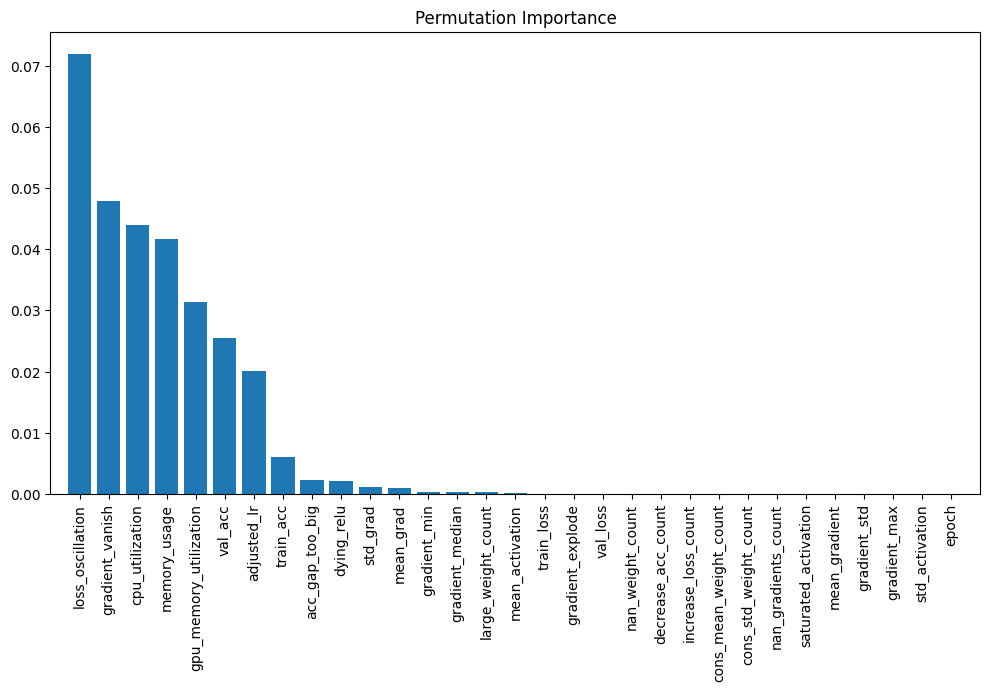

In [46]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
indices = result.importances_mean.argsort()[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], result.importances_mean[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Permutation Importance")
plt.bar(range(X_train.shape[1]), result.importances_mean[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()


Feature ranking:
1. feature 26 (0.238177)
2. feature 9 (0.158809)
3. feature 23 (0.102656)
4. feature 8 (0.069572)
5. feature 7 (0.062794)
6. feature 4 (0.054564)
7. feature 24 (0.049429)
8. feature 29 (0.048031)
9. feature 28 (0.040292)
10. feature 2 (0.036756)
11. feature 5 (0.033614)
12. feature 27 (0.026129)
13. feature 30 (0.023376)
14. feature 10 (0.019147)
15. feature 6 (0.018741)
16. feature 21 (0.009069)
17. feature 22 (0.008843)
18. feature 3 (0.000000)
19. feature 1 (0.000000)
20. feature 15 (0.000000)


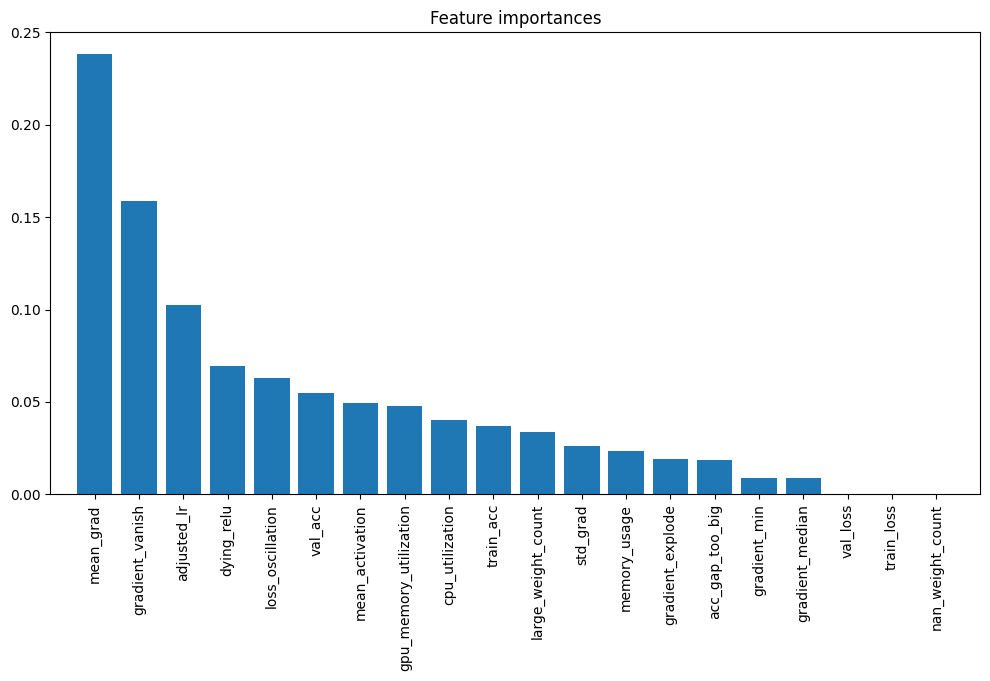

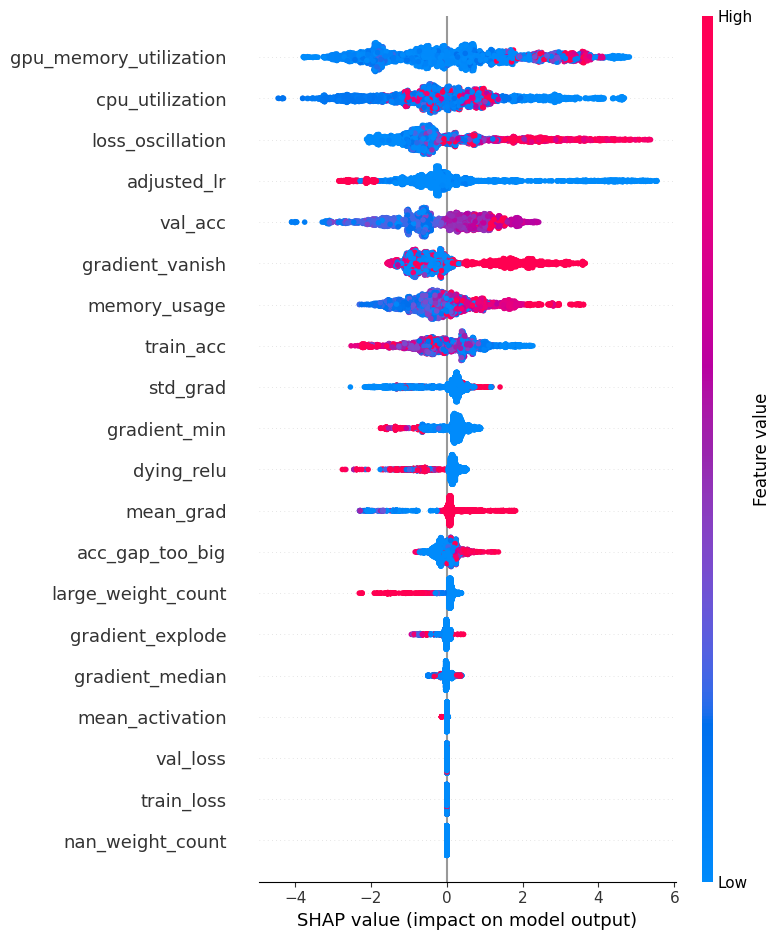

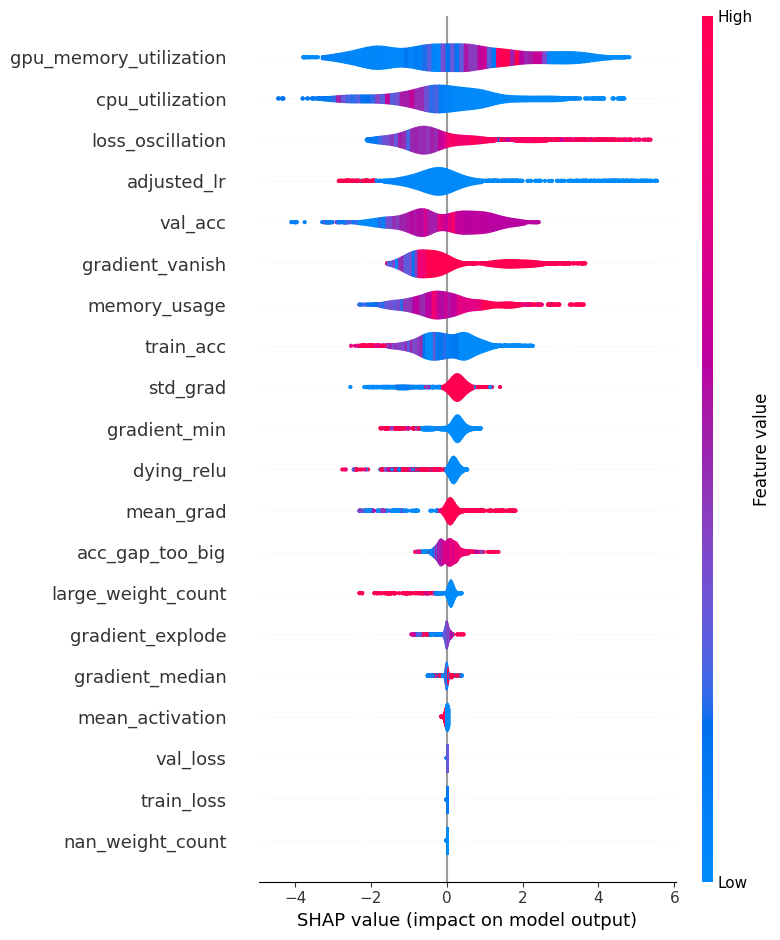

In [50]:
import shap
import xgboost as xgb

model = xgb.XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
# print top 20 features with their name and index and score
feature_names = X.columns
feature_scores = model.feature_importances_
indices = np.argsort(feature_scores)[::-1]
print("Feature ranking:")
for f in range(20):
    print("%d. feature %d (%f)" % (f + 1, indices[f], feature_scores[indices[f]]))

# plot the top 20 features
feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Feature importances")
plt.bar(range(20), feature_scores[indices][:20], align="center")
plt.xticks(range(20), feature_names[:20], rotation=90)
plt.xlim([-1, 20])
plt.show()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)
feature_names = X.columns
shap.summary_plot(shap_values, X_train, feature_names=feature_names)
shap.summary_plot(shap_values, X_train, feature_names=feature_names, plot_type='violin')

Feature ranking:
1. feature 27 (1.970473)
2. feature 21 (1.326055)
3. feature 23 (-1.129389)
4. feature 0 (-0.992857)
5. feature 22 (-0.916423)
6. feature 19 (-0.897530)
7. feature 26 (0.885192)
8. feature 10 (-0.757364)
9. feature 7 (0.743726)
10. feature 29 (0.589937)
11. feature 3 (0.553826)
12. feature 1 (0.529217)
13. feature 24 (-0.432184)
14. feature 9 (0.425315)
15. feature 8 (-0.347787)
16. feature 30 (0.278417)
17. feature 2 (-0.247211)
18. feature 6 (-0.228132)
19. feature 18 (-0.226408)
20. feature 4 (0.175098)
21. feature 5 (0.165839)
22. feature 20 (-0.146232)
23. feature 25 (-0.100100)
24. feature 28 (0.023915)
25. feature 14 (0.000000)
26. feature 13 (0.000000)
27. feature 12 (0.000000)
28. feature 11 (0.000000)
29. feature 16 (0.000000)
30. feature 17 (0.000000)
31. feature 15 (0.000000)


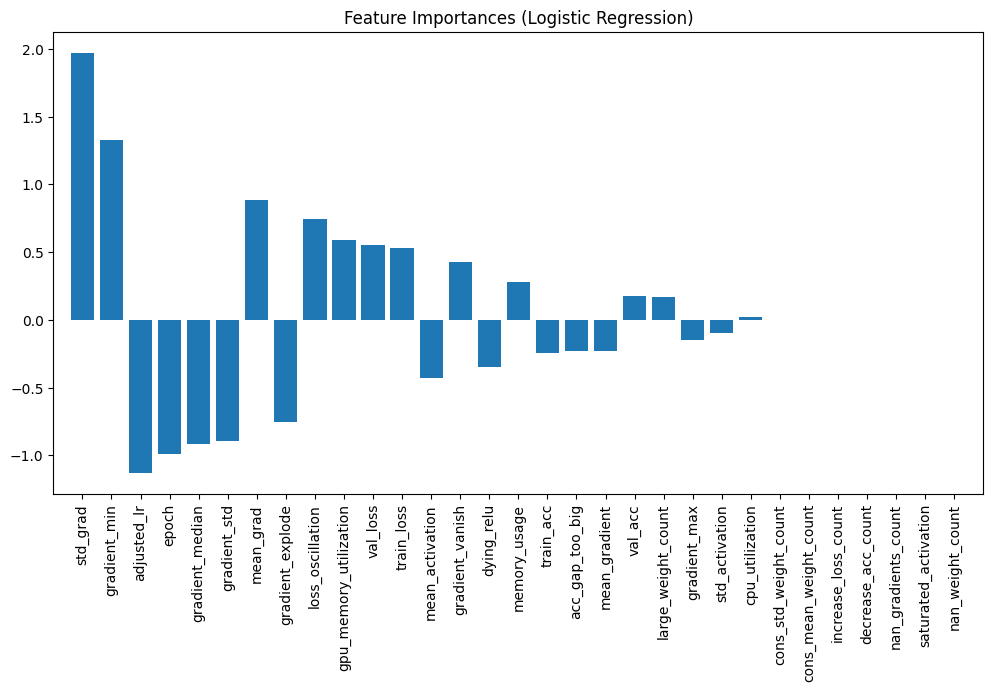

In [52]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
importance = model.coef_[0]
indices = np.argsort(np.abs(importance))[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importance[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Logistic Regression)")
plt.bar(range(X_train.shape[1]), importance[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()


# Tree-based classifier

In [53]:

# def run_models_classification_report(X_train, X_test, y_train, y_test, verbose=True):
#     models = {
#         'LogisticRegression': LogisticRegression(max_iter=1000),
#         'DecisionTree': DecisionTreeClassifier(),
#         'RandomForest': RandomForestClassifier(),
#         'SVC': SVC(max_iter=1000),
#         'KNeighbors': KNeighborsClassifier(),
#         'MLP': MLPClassifier(max_iter=1000),
#         'GradientBoosting': GradientBoostingClassifier(),
#         'AdaBoost': AdaBoostClassifier(),
#         'Bagging': BaggingClassifier(),
#         'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
#     }
    
#     results = {}
#     cv_results = {}

#     for model_name, model in tqdm(models.items(), desc='Training Models', total=len(models)):
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)
#         results[model_name] = classification_report(y_test, y_pred, output_dict=True)
        
#         cv_scores = cross_val_score(model, X_train, y_train, cv=5)
#         cv_results[model_name] = cv_scores
        
#         if verbose:
#             print(model_name)
#             print("Classification Report:")
#             print(classification_report(y_test, y_pred))
#             print("Cross-Validation Scores:")
#             print(cv_scores)
#             print("Mean CV Score:", cv_scores.mean())
#             print("Standard Deviation of CV Scores:", cv_scores.std())
#             print()
            
#     return results, cv_results

# # Run the models
# results, cv_results = run_models_classification_report(X_train, X_test, y_train, y_test, verbose=False)

# for model_name in results.keys():
#     print(model_name)
#     print("Classification Report:")
#     print(results[model_name])
#     print("Cross-Validation Scores:")
#     print(cv_results[model_name])
#     print("Mean CV Score:", cv_results[model_name].mean())
#     print("Standard Deviation of CV Scores:", cv_results[model_name].std())
#     print()

Training Models:  30%|███       | 3/10 [00:02<00:05,  1.34it/s]c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinM

LogisticRegression
Classification Report:
{'0': {'precision': 0.7870813397129187, 'recall': 0.6985138004246284, 'f1-score': 0.7401574803149606, 'support': 471.0}, '1': {'precision': 0.6780045351473923, 'recall': 0.770618556701031, 'f1-score': 0.721351025331725, 'support': 388.0}, 'accuracy': 0.7310826542491269, 'macro avg': {'precision': 0.7325429374301555, 'recall': 0.7345661785628297, 'f1-score': 0.7307542528233428, 'support': 859.0}, 'weighted avg': {'precision': 0.7378126549964761, 'recall': 0.7310826542491269, 'f1-score': 0.7316628301013455, 'support': 859.0}}
Cross-Validation Scores:
[0.7147016  0.69577875 0.70451237 0.73071325 0.71615721]
Mean CV Score: 0.712372634643377
Standard Deviation of CV Scores: 0.01177510824812615

DecisionTree
Classification Report:
{'0': {'precision': 0.9704016913319239, 'recall': 0.9745222929936306, 'f1-score': 0.972457627118644, 'support': 471.0}, '1': {'precision': 0.9689119170984456, 'recall': 0.9639175257731959, 'f1-score': 0.9664082687338501, 's

In [55]:
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
clf.fit(X_train, y_train)
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
k = 20
X_train_selected = X_train[:, indices[:k]]
X_test_selected = X_test[:, indices[:k]]
print("Feature ranking:")
for f in range(X_train_selected.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],  
    'max_features': ['sqrt', 'log2'] 
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True),
    param_grid=param_grid,
    cv=5, 
    verbose=2,
    n_jobs=-1
)
grid_search.fit(X_train_selected, y_train)
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test_selected)
target_names = [str(cat) for cat in encoder.categories_[0]]

print(classification_report(y_test, y_pred, target_names=target_names))
print("OOB Score of Best Model: ", best_clf.oob_score_)
print("Best Hyperparameters:", grid_search.best_params_)


Feature ranking:
1. feature 29 (0.159349)
2. feature 28 (0.121909)
3. feature 2 (0.108828)
4. feature 30 (0.100276)
5. feature 4 (0.095911)
6. feature 7 (0.093067)
7. feature 23 (0.085861)
8. feature 9 (0.073475)
9. feature 6 (0.033602)
10. feature 26 (0.026225)
11. feature 8 (0.022046)
12. feature 21 (0.013342)
13. feature 27 (0.013188)
14. feature 10 (0.013160)
15. feature 5 (0.011129)
16. feature 22 (0.008652)
17. feature 25 (0.004342)
18. feature 24 (0.004334)
19. feature 0 (0.002823)
20. feature 19 (0.002437)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       471
           1       0.99      0.96      0.98       388

    accuracy                           0.98       859
   macro avg       0.98      0.98      0.98       859
weighted avg       0.98      0.98      0.98       859

OOB Score of Best Model:  0.9839883551673945
Best Hyperparameters: {'max_depth': None, 'm

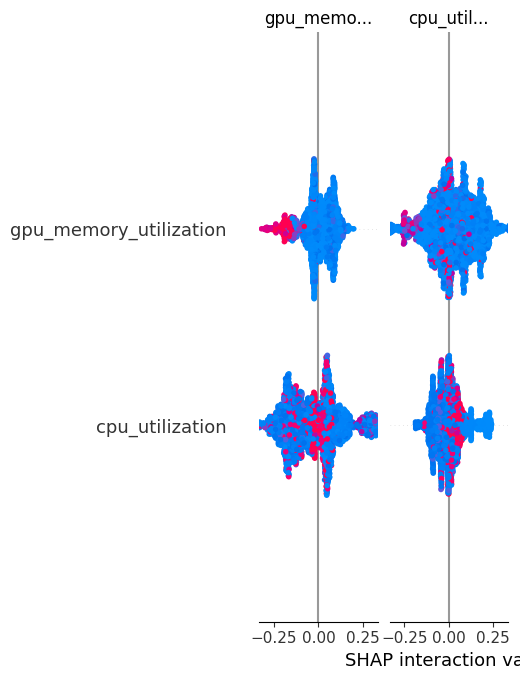

<Figure size 640x480 with 0 Axes>

In [58]:
target_names = ['Not Loss', 'Loss'] 

explainer = LimeTabularExplainer(
    training_data=X_train_selected,  
    feature_names=[f'feature_{i}' for i in range(X_train_selected.shape[1])],  
    class_names=target_names,  
    mode='classification'
)

i = 2
exp = explainer.explain_instance(X_test_selected[i], best_clf.predict_proba, num_features=10)
exp.show_in_notebook(show_table=True, show_all=False)
plt.savefig('lime_explanation.png')